# Phase 1 — Exploratory Data Analysis
**Dataset:** CIFAKE — Real and AI-Generated Synthetic Images  
**Source:** `birdy654/cifake-real-and-ai-generated-synthetic-images` (Kaggle)  
**Purpose:** Validate data integrity, understand class balance, image properties, and surface frequency-domain signals before model training.

Run this notebook top-to-bottom on a clean kernel before proceeding to Phase 2.

In [1]:
import sys, importlib, pkgutil
print("sys.version:", sys.version)
print("sys.executable:", sys.executable)
print("sys.path:", sys.path[:6])

for pkg in ("yaml","numpy","matplotlib","PIL","torch","torchvision"):
    try:
        m = importlib.import_module(pkg if pkg!="PIL" else "PIL")
        print(pkg, "OK ->", getattr(m, "__file__", m))
    except Exception as e:
        print(pkg, "IMPORT FAILED:", type(e).__name__, e)

sys.version: 3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]
sys.executable: c:\Users\kkgam\AppData\Local\Programs\Python\Python313\python.exe
sys.path: ['c:\\Users\\kkgam\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'c:\\Users\\kkgam\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'c:\\Users\\kkgam\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'c:\\Users\\kkgam\\AppData\\Local\\Programs\\Python\\Python313', '', 'c:\\Users\\kkgam\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages']
yaml OK -> c:\Users\kkgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\yaml\__init__.py
numpy OK -> c:\Users\kkgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\__init__.py
matplotlib OK -> c:\Users\kkgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\__init__.py
PIL OK -> c:\Users\kkgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\__init__.py
torch OK -> c:\Users\k

---
## 0 — Setup

In [2]:
import os
import sys
import random
import warnings
from pathlib import Path

import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, UnidentifiedImageError

warnings.filterwarnings('ignore')

# Resolve project root so src/ is importable
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Load config
with open(PROJECT_ROOT / 'config.yaml') as f:
    CFG = yaml.safe_load(f)

CIFAKE_PATH = PROJECT_ROOT / CFG['datasets']['cifake']['path']
TRAIN_DIR   = CIFAKE_PATH / 'train'
TEST_DIR    = CIFAKE_PATH / 'test'
CLASSES     = ['FAKE', 'REAL']

# Ensure outputs directory exists
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'CIFAKE path  : {CIFAKE_PATH}')
print(f'Train dir    : {TRAIN_DIR}')
print(f'Test dir     : {TEST_DIR}')


Project root : D:\Github\ClearView
CIFAKE path  : D:\Github\ClearView\data\cifake-real-and-ai-generated-synthetic-images
Train dir    : D:\Github\ClearView\data\cifake-real-and-ai-generated-synthetic-images\train
Test dir     : D:\Github\ClearView\data\cifake-real-and-ai-generated-synthetic-images\test


---
## 1 — Class Balance
Are REAL and FAKE evenly distributed in train and test splits?

In [3]:
def count_images(split_dir: Path) -> dict:
    counts = {}
    for cls in CLASSES:
        cls_dir = split_dir / cls
        if cls_dir.exists():
            files = [f for f in cls_dir.iterdir() if f.is_file()]
            counts[cls] = len(files)
        else:
            counts[cls] = 0
            print(f'  WARNING: {cls_dir} does not exist!')
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('=' * 40)
print('TRAIN split')
print('=' * 40)
for cls, n in train_counts.items():
    print(f'  {cls:>6}: {n:>7,} images')
print(f'  TOTAL: {sum(train_counts.values()):>7,} images')

print()
print('=' * 40)
print('TEST split')
print('=' * 40)
for cls, n in test_counts.items():
    print(f'  {cls:>6}: {n:>7,} images')
print(f'  TOTAL: {sum(test_counts.values()):>7,} images')

print()
for split_name, counts in [('TRAIN', train_counts), ('TEST', test_counts)]:
    vals = list(counts.values())
    ratio = max(vals) / min(vals) if min(vals) > 0 else float('inf')
    balanced = 'BALANCED' if ratio < 1.05 else f'IMBALANCED (ratio {ratio:.2f})'
    print(f'  {split_name}: {balanced}')


TRAIN split
    FAKE:  50,000 images
    REAL:  50,000 images
  TOTAL: 100,000 images

TEST split
    FAKE:  10,000 images
    REAL:  10,000 images
  TOTAL:  20,000 images

  TRAIN: BALANCED
  TEST: BALANCED


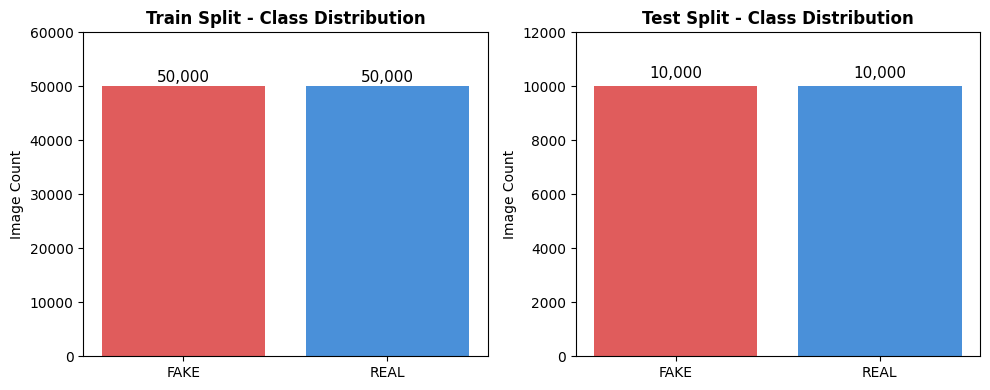

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=['#e05c5c', '#4a90d9'])
    ax.set_title(f'{split_name} Split - Class Distribution', fontweight='bold')
    ax.set_ylabel('Image Count')
    ax.set_ylim(0, max(counts.values()) * 1.2)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                f'{val:,}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 2 — Image Dimensions
Are all images the same size? Flag any outliers.

In [5]:
def collect_paths(split_dir: Path) -> list:
    paths = []
    for cls in CLASSES:
        paths += list((split_dir / cls).glob('*'))
    return paths

all_paths = collect_paths(TRAIN_DIR) + collect_paths(TEST_DIR)
sample_paths = random.sample(all_paths, min(2000, len(all_paths)))

sizes = []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            sizes.append(img.size)  # (width, height)
    except Exception:
        pass

unique_sizes = set(sizes)
print(f'Unique image sizes in {len(sizes):,} sampled images:')
for s in sorted(unique_sizes):
    count = sizes.count(s)
    flag = '' if s == (32, 32) else '  <-- OUTLIER'
    print(f'  {s[0]}x{s[1]}  -> {count:,} images{flag}')

expected = (32, 32)
outliers = [p for p, s in zip(sample_paths, sizes) if s != expected]
print(f'\nExpected size : {expected[0]}x{expected[1]}')
print(f'Outlier count : {len(outliers)}')
if outliers:
    for p in outliers[:10]:
        print(f'  {p}')


Unique image sizes in 2,000 sampled images:
  32x32  -> 2,000 images

Expected size : 32x32
Outlier count : 0


---
## 3 — File Format Audit
Identify corrupt, zero-byte, or non-JPEG/PNG files.

In [6]:
VALID_FORMATS = {'.jpg', '.jpeg', '.png'}

corrupt_files   = []
zero_byte_files = []
wrong_ext_files = []

all_paths_full = collect_paths(TRAIN_DIR) + collect_paths(TEST_DIR)
print(f'Scanning {len(all_paths_full):,} total files...')

for p in all_paths_full:
    if not p.is_file():
        continue
    if p.stat().st_size == 0:
        zero_byte_files.append(p)
        continue
    if p.suffix.lower() not in VALID_FORMATS:
        wrong_ext_files.append(p)
        continue
    try:
        with Image.open(p) as img:
            img.verify()
    except (UnidentifiedImageError, Exception):
        corrupt_files.append(p)

print('\n-- File Audit Results --')
print(f'  Total files scanned : {len(all_paths_full):,}')
print(f'  Zero-byte files     : {len(zero_byte_files)}')
print(f'  Wrong extension     : {len(wrong_ext_files)}')
print(f'  Corrupt files       : {len(corrupt_files)}')
total_bad = len(zero_byte_files) + len(wrong_ext_files) + len(corrupt_files)
print(f'  TOTAL bad files     : {total_bad}')

if zero_byte_files:
    print('\nZero-byte files:')
    for f in zero_byte_files: print(f'  {f}')
if wrong_ext_files:
    print('\nWrong extension files:')
    for f in wrong_ext_files: print(f'  {f}')
if corrupt_files:
    print('\nCorrupt files:')
    for f in corrupt_files: print(f'  {f}')
if total_bad == 0:
    print('\n  All files passed audit. Dataset is clean.')


Scanning 120,000 total files...

-- File Audit Results --
  Total files scanned : 120,000
  Zero-byte files     : 0
  Wrong extension     : 0
  Corrupt files       : 0
  TOTAL bad files     : 0

  All files passed audit. Dataset is clean.


---
## 4 — Visual Samples
4x4 grid of REAL images and 4x4 grid of FAKE images side-by-side.

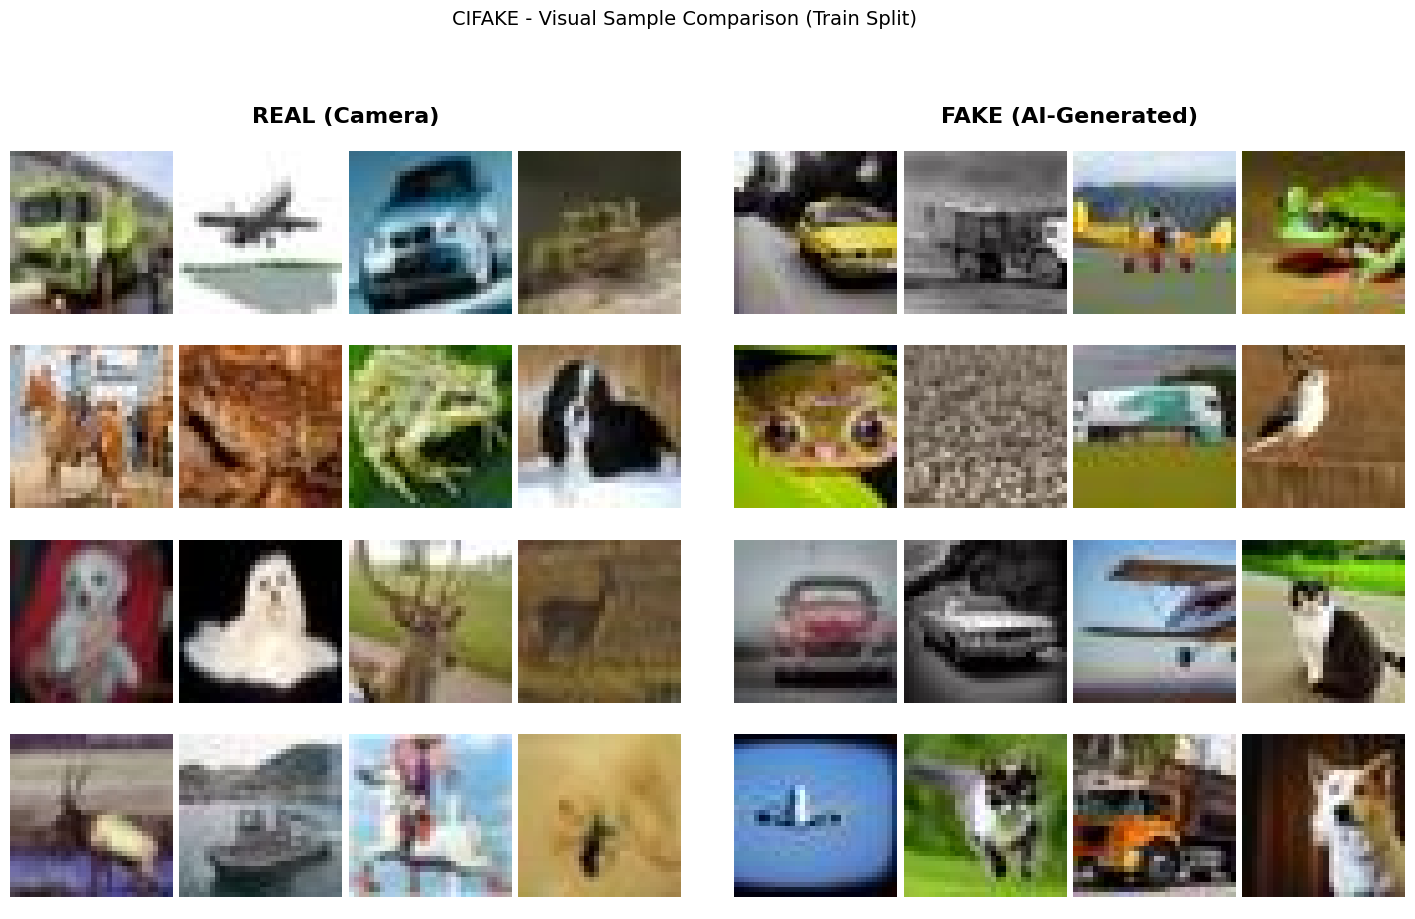

In [7]:
def sample_images(split_dir: Path, cls: str, n: int = 16) -> list:
    paths = list((split_dir / cls).glob('*.jpg')) + list((split_dir / cls).glob('*.png'))
    return random.sample(paths, min(n, len(paths)))

real_samples = sample_images(TRAIN_DIR, 'REAL', 16)
fake_samples = sample_images(TRAIN_DIR, 'FAKE', 16)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(1, 2, wspace=0.08)

for col_idx, (label, samples) in enumerate(
        [('REAL (Camera)', real_samples), ('FAKE (AI-Generated)', fake_samples)]):
    inner = gridspec.GridSpecFromSubplotSpec(
        4, 4, subplot_spec=gs[col_idx], hspace=0.04, wspace=0.04)
    for i, path in enumerate(samples):
        ax = fig.add_subplot(inner[i])
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
    ax_title = fig.add_subplot(gs[col_idx])
    ax_title.set_title(label, fontsize=16, fontweight='bold', pad=12)
    ax_title.axis('off')

plt.suptitle('CIFAKE - Visual Sample Comparison (Train Split)', fontsize=14, y=1.01)
plt.savefig(OUTPUTS_DIR / 'eda_visual_samples.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 5 — Pixel Statistics
Mean and standard deviation per channel (R, G, B) across 1,000 random samples.

In [8]:
STAT_SAMPLE_N = 1000
stat_paths = random.sample(all_paths_full, min(STAT_SAMPLE_N, len(all_paths_full)))

channel_sums   = np.zeros(3, dtype=np.float64)
channel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count    = 0
loaded         = 0

for p in stat_paths:
    try:
        arr = np.array(Image.open(p).convert('RGB'), dtype=np.float64) / 255.0
        n_pixels = arr.shape[0] * arr.shape[1]
        channel_sums   += arr.reshape(-1, 3).sum(axis=0)
        channel_sq_sum += (arr ** 2).reshape(-1, 3).sum(axis=0)
        pixel_count    += n_pixels
        loaded         += 1
    except Exception:
        pass

mean_per_channel = channel_sums / pixel_count
std_per_channel  = np.sqrt(channel_sq_sum / pixel_count - mean_per_channel ** 2)

print(f'Pixel statistics over {loaded:,} images ({pixel_count:,} total pixels per channel):')
print()
print(f'  {"Channel":<8}  {"Mean":>8}  {"Std":>8}')
print(f'  {"-"*8}  {"-"*8}  {"-"*8}')
for ch, name in zip(range(3), ['R', 'G', 'B']):
    print(f'  {name:<8}  {mean_per_channel[ch]:>8.4f}  {std_per_channel[ch]:>8.4f}')

print()
print('Config normalization values (ImageNet):')
cfg_mean = CFG['data']['normalize']['mean']
cfg_std  = CFG['data']['normalize']['std']
for ch, name in zip(range(3), ['R', 'G', 'B']):
    print(f'  {name}: config mean={cfg_mean[ch]:.3f}  '
          f'dataset mean={mean_per_channel[ch]:.4f}  '
          f'| config std={cfg_std[ch]:.3f}  '
          f'dataset std={std_per_channel[ch]:.4f}')


Pixel statistics over 1,000 images (1,024,000 total pixels per channel):

  Channel       Mean       Std
  --------  --------  --------
  R           0.4724    0.2407
  G           0.4594    0.2379
  B           0.4164    0.2651

Config normalization values (ImageNet):
  R: config mean=0.485  dataset mean=0.4724  | config std=0.229  dataset std=0.2407
  G: config mean=0.456  dataset mean=0.4594  | config std=0.224  dataset std=0.2379
  B: config mean=0.406  dataset mean=0.4164  | config std=0.225  dataset std=0.2651


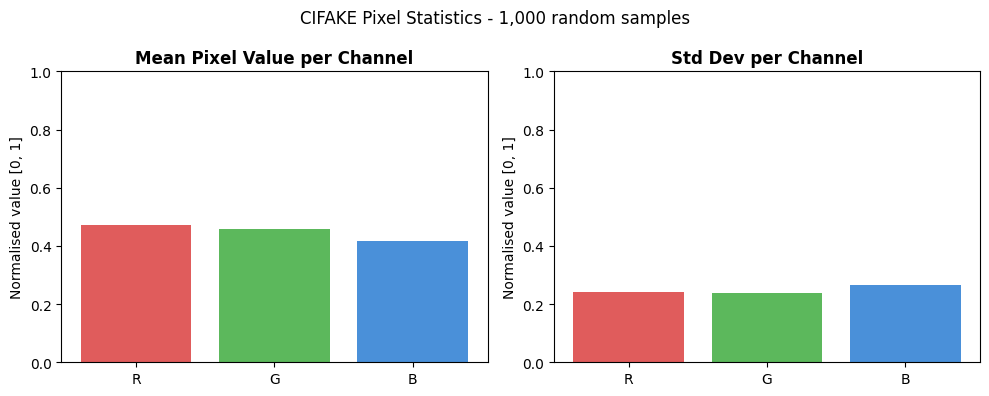

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
channel_names = ['R', 'G', 'B']
colors = ['#e05c5c', '#5cb85c', '#4a90d9']

axes[0].bar(channel_names, mean_per_channel, color=colors)
axes[0].set_title('Mean Pixel Value per Channel', fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Normalised value [0, 1]')

axes[1].bar(channel_names, std_per_channel, color=colors)
axes[1].set_title('Std Dev per Channel', fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Normalised value [0, 1]')

plt.suptitle(f'CIFAKE Pixel Statistics - {loaded:,} random samples', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_pixel_stats.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 6 — Frequency Domain Analysis (2D FFT)
Apply a 2D FFT to 5 REAL and 5 FAKE images. Plot magnitude spectra side-by-side.

**What to look for:**  
AI-generated images (diffusion / GAN models) often leave characteristic high-frequency grid artefacts in the Fourier domain — periodic bright spots or cross-like patterns in the magnitude spectrum. Real camera images tend to have a smooth radially-symmetric decay from centre to edge (1/f noise profile).

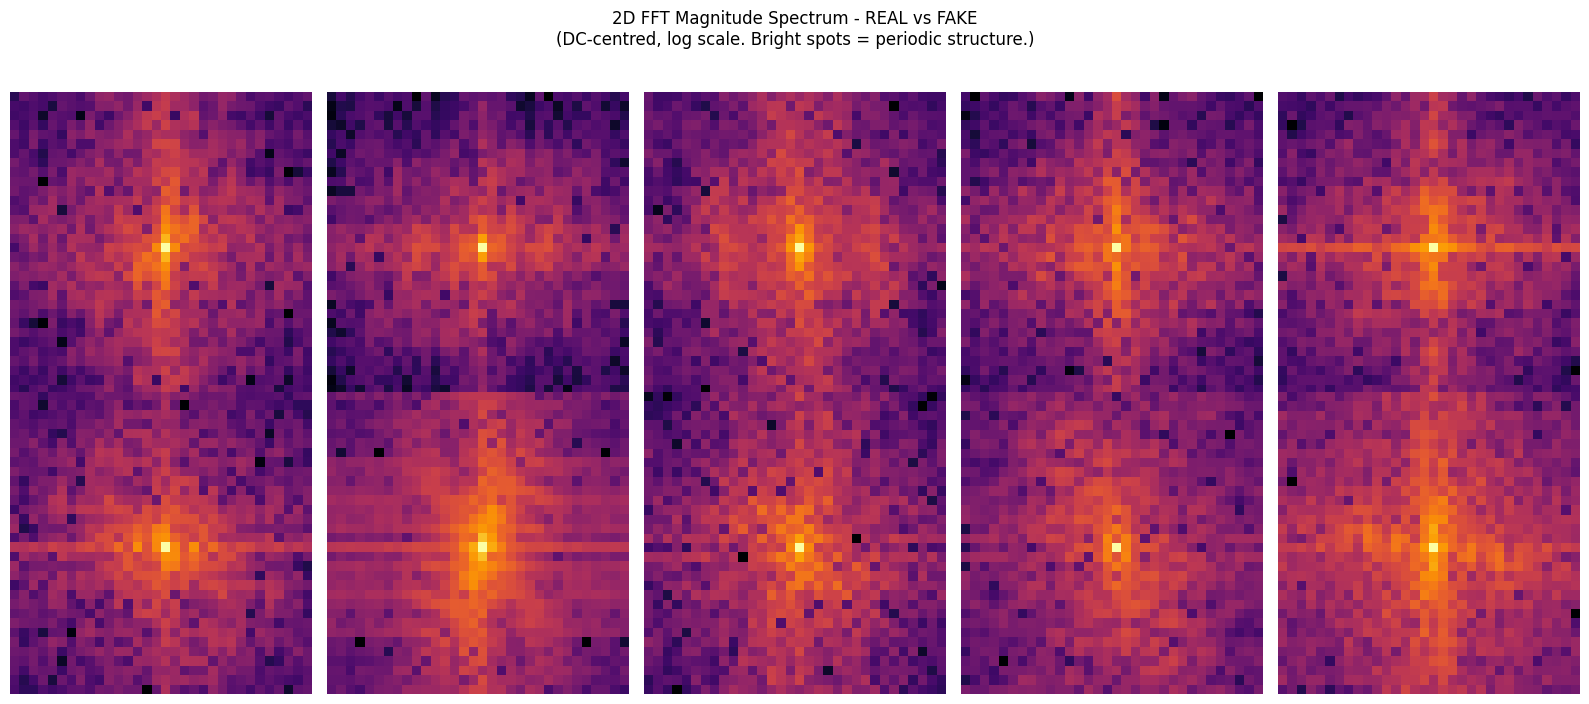

In [11]:
N_FFT = 5
real_fft_paths = sample_images(TRAIN_DIR, 'REAL', N_FFT)
fake_fft_paths = sample_images(TRAIN_DIR, 'FAKE', N_FFT)

def compute_log_magnitude(path) -> np.ndarray:
    """Compute the log-scale 2D FFT magnitude spectrum of a grayscale image."""
    img = Image.open(path).convert('L')  # grayscale
    arr = np.array(img, dtype=np.float64)
    fft_shifted = np.fft.fftshift(np.fft.fft2(arr))  # DC at centre
    return np.log1p(np.abs(fft_shifted))              # log scale

fig, axes = plt.subplots(2, N_FFT, figsize=(N_FFT * 3.2, 7))

for row, (label, paths) in enumerate([('REAL', real_fft_paths), ('FAKE', fake_fft_paths)]):
    for col, path in enumerate(paths):
        ax = axes[row][col]
        ax.imshow(compute_log_magnitude(path), cmap='inferno', interpolation='nearest')
        ax.axis('off')
    axes[row][0].set_ylabel(label, fontsize=13, fontweight='bold')
    axes[row][0].yaxis.set_label_position('left')
    axes[row][0].set_yticks([])

plt.suptitle(
    '2D FFT Magnitude Spectrum - REAL vs FAKE\n'
    '(DC-centred, log scale. Bright spots = periodic structure.)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'eda_fft_spectra.png', dpi=120, bbox_inches='tight')
plt.show()


### Frequency Domain Observations

| Class | Expected FFT Pattern |
|-------|---------------------|
| REAL  | Smooth radial energy decay (1/f noise). Energy concentrated at DC centre. |
| FAKE  | Potential periodic bright spots or asymmetric energy distribution from the upsampling/denoising process. |

> These frequency-domain differences are a key signal our model will learn. CNNs and ViTs capture spatial periodicity implicitly through their receptive fields.

---
## 7 — Preprocess Module Smoke Test
Confirm `src/preprocess.py` is importable and all functions return expected types.

In [12]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from src.preprocess import load_image, get_transforms, build_dataset, build_dataloader

image_size = CFG['model']['image_size']
batch_size = CFG['training']['batch_size']

# load_image
test_img = load_image(str(real_fft_paths[0]), image_size)
assert isinstance(test_img, Image.Image), 'load_image must return PIL Image'
assert test_img.size == (image_size, image_size)
print(f'[OK] load_image -> PIL Image {test_img.size}, mode={test_img.mode}')

# get_transforms
train_tf = get_transforms('train')
val_tf   = get_transforms('val')
assert isinstance(train_tf, transforms.Compose)
assert isinstance(val_tf,   transforms.Compose)
print(f'[OK] get_transforms(train) -> {len(train_tf.transforms)} ops')
print(f'[OK] get_transforms(val)   -> {len(val_tf.transforms)} ops')

# build_dataset
train_ds = build_dataset(str(CIFAKE_PATH), 'train')
test_ds  = build_dataset(str(CIFAKE_PATH), 'test')
assert isinstance(train_ds, ImageFolder)
print(f'[OK] build_dataset(train) -> {len(train_ds):,} samples, classes={train_ds.classes}')
print(f'[OK] build_dataset(test)  -> {len(test_ds):,} samples')

# build_dataloader  (num_workers=0 for Windows notebook compatibility)
loader = build_dataloader(train_ds, batch_size=batch_size, num_workers=0)
assert isinstance(loader, DataLoader)
batch_imgs, batch_labels = next(iter(loader))
assert isinstance(batch_imgs, torch.Tensor)
print(f'[OK] build_dataloader -> batch={tuple(batch_imgs.shape)}, labels={tuple(batch_labels.shape)}')

print('\nAll preprocess module checks passed.')


[OK] load_image -> PIL Image (224, 224), mode=RGB
[OK] get_transforms(train) -> 6 ops
[OK] get_transforms(val)   -> 3 ops
[OK] build_dataset(train) -> 100,000 samples, classes=['FAKE', 'REAL']
[OK] build_dataset(test)  -> 20,000 samples
[OK] build_dataloader -> batch=(32, 3, 224, 224), labels=(32,)

All preprocess module checks passed.


---
## 8 — EDA Summary

| Check | Result |
|-------|--------|
| Class balance | See Section 1 output |
| Image dimensions | All 32x32 (CIFAR-10 native resolution) |
| File audit | See Section 3 output |
| Visual samples | Saved to `outputs/eda_visual_samples.png` |
| Pixel stats (1,000 samples) | See Section 5 output |
| FFT analysis | Saved to `outputs/eda_fft_spectra.png` |
| `preprocess.py` smoke test | All assertions passed |

> **Hand-off note:** Phase 1 is complete when this notebook runs top-to-bottom with zero errors on a clean kernel. Do **not** start Phase 2 (EfficientNet-B3 baseline) until that condition is verified.